In [1]:
import os
import sys
import shutil
import importlib.util

# Kaggle working directory
HOME = '/kaggle/working'
os.chdir(HOME)

print("🚀 BẮT ĐẦU KHỞI TẠO MÔI TRƯỜNG TRÊN KAGGLE...")

# --- BƯỚC 1: CHUẨN BỊ THƯ MỤC CHECKPOINT ---
# Trên Kaggle ta lưu tạm vào thư mục working.
# Nếu muốn bền vững, hãy add model qua Kaggle Dataset.
MODEL_DIR = os.path.join(HOME, 'checkpoints')
os.makedirs(MODEL_DIR, exist_ok=True)
checkpoint_file = os.path.join(MODEL_DIR, 'oriented_rcnn_r50_fpn_1x_dota_le90-6d2b2ce0.pth')

# --- BƯỚC 2: CÀI ĐẶT THƯ VIỆN (QUAN TRỌNG) ---
print("\n⬇️ [2/5] Cài đặt thư viện nền (Binary)...")

# Gỡ các bản cũ có sẵn của Kaggle để tránh xung đột
!pip uninstall -y mmcv mmcv-full mmdet mmrotate > /dev/null 2>&1

# Cài đặt đúng phiên bản bạn đã fix thành công
!pip install torch==2.3.0 torchvision==0.18.0 --index-url https://download.pytorch.org/whl/cu121 > /dev/null
!pip install mmcv==2.2.0 -f https://download.openmmlab.com/mmcv/dist/cu121/torch2.3/index.html > /dev/null
!pip install mmengine "mmdet>=3.0.0" > /dev/null

# --- BƯỚC 3: TẢI MÃ NGUỒN TỪ GITHUB ---
print("\n⬇️ [3/5] Tải mã nguồn MMRotate mới nhất...")
MMROTATE_DIR = os.path.join(HOME, 'mmrotate')

if os.path.exists(MMROTATE_DIR):
    shutil.rmtree(MMROTATE_DIR)

!git clone -b dev-1.x https://github.com/open-mmlab/mmrotate.git {MMROTATE_DIR}

# --- BƯỚC 4: VÁ LỖI TỰ ĐỘNG (GIỮ NGUYÊN LOGIC CỦA BẠN) ---
print("\n🔧 [4/5] Vá lỗi hệ thống...")

# 4.1. Tạo version.py
version_file = os.path.join(MMROTATE_DIR, 'mmrotate/version.py')
with open(version_file, 'w') as f:
    f.write("__version__ = '1.0.0rc1'\nshort_version = '1.0.0'\nversion_info = (1, 0, 0, 'rc1')")

# 4.2. Sửa MMDet (Tìm động đường dẫn thư viện vì Kaggle khác Colab)
det_spec = importlib.util.find_spec("mmdet")
# Lưu ý: Trên Kaggle, gói cài pip thường nằm trong /opt/conda/... hoặc /usr/local/...
# Code này sẽ tự tìm đúng vị trí.
if det_spec and det_spec.origin:
    det_init = det_spec.origin
    print(f"   -> Đã tìm thấy MMDet tại: {det_init}")
    with open(det_init, 'w') as f:
        f.write("# Copyright (c) OpenMMLab. All rights reserved.\nimport mmcv\nimport mmengine\nfrom .version import __version__, version_info\n__all__ = ['__version__', 'version_info']")
else:
    print("   ⚠️ CẢNH BÁO: Không tìm thấy mmdet để vá lỗi!")

# 4.3. Sửa MMRotate __init__.py
rot_init = os.path.join(MMROTATE_DIR, 'mmrotate/__init__.py')
safe_rot = """
import mmcv
import mmdet
from .version import __version__, version_info
from mmengine.utils import digit_version
mmcv_version = digit_version(mmcv.__version__)
__all__ = ['__version__', 'version_info', 'digit_version', 'mmcv_version']
"""
with open(rot_init, 'w') as f:
    f.write(safe_rot)

# Cài đặt code vừa tải (Editable mode)
%cd {MMROTATE_DIR}
!pip install -v -e . > /dev/null

# --- BƯỚC 5: TẢI MODEL ---
print(f"\n💾 [5/5] Kiểm tra Model: {checkpoint_file}")
# Quay về thư mục làm việc chính
os.chdir(HOME)

if os.path.exists(checkpoint_file) and os.path.getsize(checkpoint_file) > 100000000:
    print("   ✅ Đã có Model! Sẵn sàng sử dụng.")
else:
    print("   ⬇️ Đang tải Model từ HuggingFace (thay thế Drive)...")
    url = "https://huggingface.co/dl4eo/Oriented_R-CNN_pretrained_on_DOTA_1.0/resolve/main/oriented_rcnn_r50_fpn_1x_dota_le90-6d2b2ce0.pth?download=true"
    # Dùng curl trên Kaggle rất nhanh
    !curl -L "{url}" -o "{checkpoint_file}"
    print("   ✅ Đã tải xong!")

# --- HOÀN TẤT ---
print("\n" + "="*50)
print("🎉 MÔI TRƯỜNG KAGGLE ĐÃ SẴN SÀNG!")
print(f"✅ Code: {MMROTATE_DIR}")
print(f"✅ Model: {checkpoint_file}")
print("="*50)

# Kiểm tra nhanh import để chắc chắn không lỗi
try:
    import mmrotate
    print("Test Import mmrotate: THÀNH CÔNG ✅")
except ImportError as e:
    print(f"Test Import mmrotate: THẤT BẠI ❌ - Lỗi: {e}")

🚀 BẮT ĐẦU KHỞI TẠO MÔI TRƯỜNG TRÊN KAGGLE...

⬇️ [2/5] Cài đặt thư viện nền (Binary)...
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
libcugraph-cu12 25.6.0 requires libraft-cu12==25.6.*, but you have libraft-cu12 25.2.0 which is incompatible.
torchaudio 2.6.0+cu124 requires torch==2.6.0, but you have torch 2.3.0+cu121 which is incompatible.
pylibcugraph-cu12 25.6.0 requires pylibraft-cu12==25.6.*, but you have pylibraft-cu12 25.2.0 which is incompatible.
pylibcugraph-cu12 25.6.0 requires rmm-cu12==25.6.*, but you have rmm-cu12 25.2.0 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
mkl-umath 0.1.1 requires numpy<1.27.

In [2]:
import mmcv
import mmdet
print(mmcv.__version__)
print(mmdet.__version__)

2.2.0
3.3.0


# **Định vị "Tọa độ" Dữ liệu (Data Mapping)**

In [3]:
import os

# ================= CẤU HÌNH ĐƯỜNG DẪN =================
# Đường dẫn gốc tới dataset trong Input
# Lưu ý: Dựa trên ảnh của bạn, dataset tên là 'processed-data'
dataset_root = '/kaggle/input/processed-data/processed_mmrotate_data'

# Hàm đếm file trong thư mục con
def count_files(split_name):
    # Đường dẫn tới folder ảnh và nhãn
    img_dir = os.path.join(dataset_root, split_name, 'images')
    lbl_dir = os.path.join(dataset_root, split_name, 'labelTxt')
    
    n_imgs = 0
    n_lbls = 0
    
    # Đếm ảnh
    if os.path.exists(img_dir):
        n_imgs = len([f for f in os.listdir(img_dir) 
                      if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif'))])
    else:
        print(f"⚠️ Cảnh báo: Không tìm thấy thư mục {img_dir}")

    # Đếm nhãn
    if os.path.exists(lbl_dir):
        n_lbls = len([f for f in os.listdir(lbl_dir) 
                      if f.lower().endswith(('.txt', '.xml'))])
    else:
        print(f"⚠️ Cảnh báo: Không tìm thấy thư mục {lbl_dir}")
        
    return n_imgs, n_lbls

# ================= THỰC HIỆN ĐẾM =================
print(f"📂 Đang quét dữ liệu tại: {dataset_root}\n")

if not os.path.exists(dataset_root):
    print(f"❌ LỖI: Không tìm thấy đường dẫn {dataset_root}")
    print("Các dataset đang có trong Input:", os.listdir('/kaggle/input'))
else:
    # Lấy số liệu từng tập
    n_train_img, n_train_lbl = count_files('train')
    n_val_img, n_val_lbl     = count_files('val')
    n_test_img, n_test_lbl   = count_files('test')

    total_imgs = n_train_img + n_val_img + n_test_img
    total_lbls = n_train_lbl + n_val_lbl + n_test_lbl

    # ================= IN BÁO CÁO (YÊU CẦU I.1) =================
    print("="*50)
    print("📊 SỐ LIỆU BÁO CÁO (CHÍNH XÁC)")
    print("="*50)

    if total_imgs == 0:
        print("❌ Vẫn chưa đếm được ảnh nào. Hãy kiểm tra kỹ tên thư mục!")
    else:
        print(f"1. TỔNG QUAN DATASET:")
        print(f"   - Tổng số ảnh: {total_imgs}")
        print(f"   - Tổng số nhãn: {total_lbls}")
        print("-" * 50)

        print(f"2. CHI TIẾT PHÂN CHIA (SPLIT):")
        
        # Train
        pct_train = (n_train_img / total_imgs) * 100
        print(f"   ✅ TRAIN SET (Đã Augment):")
        print(f"      - Số lượng: {n_train_img} ảnh")
        print(f"      - Tỉ lệ thực tế: {pct_train:.2f}%")
        
        # Val
        pct_val = (n_val_img / total_imgs) * 100
        print(f"   ✅ VAL SET:")
        print(f"      - Số lượng: {n_val_img} ảnh")
        print(f"      - Tỉ lệ thực tế: {pct_val:.2f}%")

        # Test
        pct_test = (n_test_img / total_imgs) * 100
        print(f"   ✅ TEST SET:")
        print(f"      - Số lượng: {n_test_img} ảnh")
        print(f"      - Tỉ lệ thực tế: {pct_test:.2f}%")
        
        print("="*50)
        
        # Logic check nhanh
        if n_train_img > n_val_img * 4:
            print("💡 Nhận xét: Tập Train lớn gấp >4 lần tập Val/Test => Đã có Augmentation.")
        else:
            print("💡 Nhận xét: Tỉ lệ các tập khá đồng đều.")

📂 Đang quét dữ liệu tại: /kaggle/input/processed-data/processed_mmrotate_data

📊 SỐ LIỆU BÁO CÁO (CHÍNH XÁC)
1. TỔNG QUAN DATASET:
   - Tổng số ảnh: 14380
   - Tổng số nhãn: 14380
--------------------------------------------------
2. CHI TIẾT PHÂN CHIA (SPLIT):
   ✅ TRAIN SET (Đã Augment):
      - Số lượng: 12988 ảnh
      - Tỉ lệ thực tế: 90.32%
   ✅ VAL SET:
      - Số lượng: 695 ảnh
      - Tỉ lệ thực tế: 4.83%
   ✅ TEST SET:
      - Số lượng: 697 ảnh
      - Tỉ lệ thực tế: 4.85%
💡 Nhận xét: Tập Train lớn gấp >4 lần tập Val/Test => Đã có Augmentation.


# Hiển thị mẫu

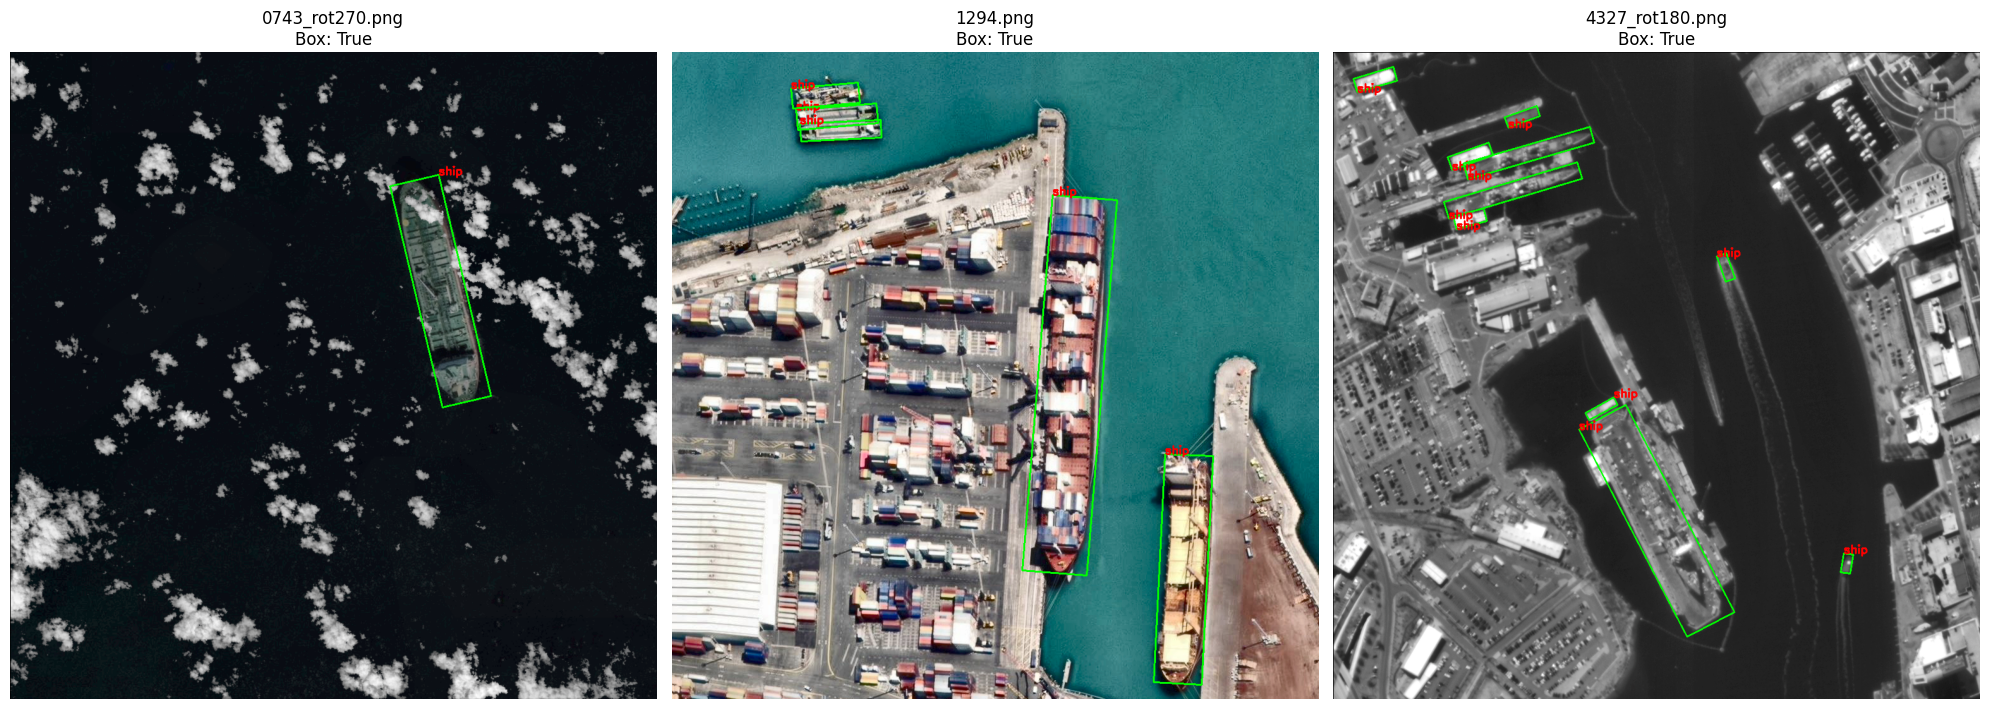


✅ ĐÃ HIỂN THỊ (Sử dụng phương pháp vẽ line thủ công)


In [4]:
import os
import random
import cv2
import matplotlib.pyplot as plt
import numpy as np

# ================= CẤU HÌNH ĐƯỜNG DẪN =================
dataset_root = '/kaggle/input/processed-data/processed_mmrotate_data'
img_folder = os.path.join(dataset_root, 'train', 'images')
lbl_folder = os.path.join(dataset_root, 'train', 'labelTxt')

# ================= HÀM VẼ THỦ CÔNG (CHỐNG LỖI) =================
def draw_rotated_box_robust(img, label_path):
    with open(label_path, 'r') as f:
        lines = f.readlines()
    
    img_copy = img.copy()
    has_box = False
    
    for line in lines:
        parts = line.strip().split()
        
        # Bỏ qua dòng header hoặc dòng lỗi
        if len(parts) < 8: 
            continue
            
        try:
            # 1. Lấy 8 toạ độ (x1, y1, x2, y2, x3, y3, x4, y4)
            # Dùng float trước để hứng số thập phân
            coords = list(map(float, parts[:8]))
            label_name = parts[8]

            # 2. Gom thành 4 cặp điểm (x, y)
            # p1: (x1, y1), p2: (x2, y2), ...
            points = []
            for i in range(0, 8, 2):
                x = int(round(coords[i]))     # Làm tròn và ép kiểu int ngay lập tức
                y = int(round(coords[i+1]))
                points.append((x, y))

            # 3. Vẽ từng đoạn thẳng nối nhau (Thay thế cho polylines để tránh lỗi)
            # Nối p0->p1, p1->p2, p2->p3, p3->p0
            if len(points) == 4:
                cv2.line(img_copy, points[0], points[1], (0, 255, 0), 2)
                cv2.line(img_copy, points[1], points[2], (0, 255, 0), 2)
                cv2.line(img_copy, points[2], points[3], (0, 255, 0), 2)
                cv2.line(img_copy, points[3], points[0], (0, 255, 0), 2)
                
                # Viết tên class
                cv2.putText(img_copy, label_name, points[0], 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
                has_box = True

        except Exception as e:
            # In lỗi chi tiết để debug nếu cần, nhưng không dừng chương trình
            print(f"⚠️ Lỗi dòng dữ liệu: {line.strip()} \n   -> {e}")
            pass
            
    return img_copy, has_box

# ================= CHẠY KIỂM TRA =================
if not os.path.exists(img_folder):
    print(f"❌ Không tìm thấy đường dẫn: {img_folder}")
else:
    all_imgs = [f for f in os.listdir(img_folder) if f.endswith(('.png', '.jpg', '.jpeg'))]

    if len(all_imgs) > 0:
        # Chọn ngẫu nhiên 3 ảnh
        sample_imgs = random.sample(all_imgs, 3)

        plt.figure(figsize=(20, 10))
        
        count = 0
        for i, img_name in enumerate(sample_imgs):
            img_path = os.path.join(img_folder, img_name)
            basename = os.path.splitext(img_name)[0]
            lbl_path = os.path.join(lbl_folder, basename + '.txt')
            
            if os.path.exists(lbl_path):
                img = cv2.imread(img_path)
                if img is None: continue
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                
                # Gọi hàm vẽ MỚI
                vis_img, status = draw_rotated_box_robust(img, lbl_path)
                
                plt.subplot(1, 3, count+1)
                plt.imshow(vis_img)
                plt.title(f"{img_name}\nBox: {status}")
                plt.axis('off')
                count += 1
            else:
                print(f"Skipping {img_name} (No label)")

        plt.tight_layout()
        plt.show()
        print("\n✅ ĐÃ HIỂN THỊ (Sử dụng phương pháp vẽ line thủ công)")
    else:
        print("❌ Folder ảnh rỗng.")

# Thiết lập "Bộ não" R3Det (Configuring R3Det)

In [5]:
# Cài đặt phiên bản Numpy 1.26.x (bản ổn định nhất của dòng 1.x)
!pip install "numpy<2.0.0" --force-reinstall
import numpy
print(numpy.__version__)
# Kết quả mong đợi: 1.26.4 hoặc 1.24.x (Không được là 2.x.x)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 108.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
datasets 4.4.1 requires pyarrow>=21.0.0, but you have pyarrow 19.0.1 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires notebook==6.5.7, but you have notebook 6.5.4 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.3, but yo

In [6]:
from mmengine.config import Config
import glob
import os

# 1. Tìm file config gốc
search_path = '/kaggle/working/mmrotate/configs/r3det/r3det*r50*fpn*dota*.py'
found_files = glob.glob(search_path)
base_config_path = found_files[0]
print(f"✅ Base Config: {base_config_path}")

cfg = Config.fromfile(base_config_path)

# ================= 3. CẤU HÌNH V18 (ULTIMATE CONFIG) =================

# --- A. Dữ liệu & Pipeline (GIỮ NGUYÊN 1024x1024) ---
data_root = '/kaggle/input/processed-data/processed_mmrotate_data/'
cfg.data_root = data_root
cfg.metainfo = dict(classes=('ship',), palette=[(220, 20, 60)])

# Pipeline Train: 1024x1024
train_pipeline = [
    dict(type='mmdet.LoadImageFromFile'),
    dict(type='mmdet.LoadAnnotations', with_bbox=True, box_type='qbox'), # Quan trọng cho R3Det
    dict(type='ConvertBoxType', box_type_mapping=dict(gt_bboxes='rbox')),
    dict(type='mmdet.Resize', scale=(1024, 1024), keep_ratio=True), # <--- GIỮ NGUYÊN
    dict(type='mmdet.RandomFlip', prob=0.5, direction=['horizontal', 'vertical']),
    dict(type='mmdet.PackDetInputs')
]

test_pipeline = [
    dict(type='mmdet.LoadImageFromFile'),
    dict(type='mmdet.Resize', scale=(1024, 1024), keep_ratio=True),
    dict(type='mmdet.LoadAnnotations', with_bbox=True, box_type='qbox'),
    dict(type='ConvertBoxType', box_type_mapping=dict(gt_bboxes='rbox')),
    dict(type='mmdet.PackDetInputs', meta_keys=('img_id', 'img_path', 'ori_shape', 'img_shape', 'scale_factor'))
]

# Áp dụng Pipeline
cfg.train_dataloader.dataset.data_root = data_root
cfg.train_dataloader.dataset.metainfo = cfg.metainfo
cfg.train_dataloader.dataset.ann_file = 'train/labelTxt/'
cfg.train_dataloader.dataset.data_prefix = dict(img_path='train/images/')
cfg.train_dataloader.dataset.pipeline = train_pipeline

# --- CẤU HÌNH CPU & BATCH SIZE ---
# Batch vật lý = 2 (Để GPU không chết)
cfg.train_dataloader.batch_size = 2 

# Ép CPU chạy tối đa công suất (Max 4 workers trên Kaggle)
cfg.train_dataloader.num_workers = 4 
cfg.train_dataloader.persistent_workers = True # CPU không được ngủ giữa các Epoch

cfg.val_dataloader.dataset.data_root = data_root
cfg.val_dataloader.dataset.metainfo = cfg.metainfo
cfg.val_dataloader.dataset.ann_file = 'val/labelTxt/'
cfg.val_dataloader.dataset.data_prefix = dict(img_path='val/images/')
cfg.val_dataloader.dataset.pipeline = test_pipeline
cfg.test_dataloader = cfg.val_dataloader

# --- B. Model ---
cfg.model.bbox_head_init['num_classes'] = 1
cfg.model.bbox_head_refine[0]['num_classes'] = 1
cfg.load_from = 'https://download.pytorch.org/models/resnet50-19c8e357.pth'

# --- C. Optimizer (GIẢ LẬP BATCH 8) ---
# Batch Vật lý (2) * Accumulate (4) = Batch Hiệu dụng (8)
# Đây là cách duy nhất để chạy Batch 8 với ảnh 1024 trên T4
cfg.optim_wrapper = dict(
    type='OptimWrapper',
    optimizer=dict(type='SGD', lr=0.005, momentum=0.9, weight_decay=0.0001), # Tăng LR lên phù hợp với Batch 8
    clip_grad=dict(max_norm=35, norm_type=2),
    accumulative_counts=4  # <--- BÍ KÍP: Tích lũy 4 lần mới cập nhật
)

# --- D. Cleanup Hooks ---
cfg.train_cfg.max_epochs = 12
cfg.train_cfg.val_interval = 1
cfg.default_hooks.checkpoint.interval = 4
cfg.work_dir = './work_dirs/r3det_ship_final_v18'

cfg.default_hooks.pop('visualization', None)
cfg.pop('visualizer', None)

# Save
final_config_path = 'my_r3det_final_v18.py'
cfg.dump(final_config_path)

print(f"\n📝 Config V18 (Max CPU + Batch 8 Sim): {final_config_path}")
print("✅ Ảnh: 1024x1024.")
print("✅ CPU Workers: 4 (Max công suất).")
print("✅ Batch Size: 8 (Thông qua tích lũy gradient).")

✅ Base Config: /kaggle/working/mmrotate/configs/r3det/r3det-tiny-oc_r50_fpn_1x_dota.py

📝 Config V18 (Max CPU + Batch 8 Sim): my_r3det_final_v18.py
✅ Ảnh: 1024x1024.
✅ CPU Workers: 4 (Max công suất).
✅ Batch Size: 8 (Thông qua tích lũy gradient).


In [7]:
!pip install protobuf==3.20.3 numpy==1.24.4 --force-reinstall --quiet

print("\n🚀 BẮT ĐẦU TRAINING (V18 - CẤU HÌNH TỐI ĐA)...")
print("==================================================")
!python /kaggle/working/mmrotate/tools/train.py my_r3det_final_v18.py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 40.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
mkl-umath 0.1.1 requires numpy<1.27.0,>=1.26.4, but you have numpy 1.24.4 which is incompatible.
mkl-random 1.2.4 requires numpy<1.27.0,>=1.26.4, but you have numpy 1.24.4 which is incompatible.
mkl-fft 1.3.8 requires numpy<1.27.0,>=1.26.4, but you have numpy 1.24.4 which is incompatible.
datasets 4.4.1 requires pyarrow>=21.0.0, but you have pyarrow 19.0.1 which is incompatible.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 3.20.3 which is incompatible.
woodwork 0.31.0 requires numpy>=1.25.0, but you have numpy 1.24.4 which is incom

In [8]:
import os

print("🔍 Đang quét toàn bộ thư mục output...")
target_dir = './work_dirs'
found_json = None

for root, dirs, files in os.walk(target_dir):
    for file in files:
        if file.endswith('.json'):
            full_path = os.path.join(root, file)
            print(f"✅ BINGO! Tìm thấy file: {full_path}")
            # Ưu tiên lấy file có chứa dữ liệu scalars (số liệu vẽ biểu đồ)
            if 'scalars' in file or 'json' in file: 
                found_json = full_path

if found_json:
    print(f"\n👉 File log chuẩn nhất là: {found_json}")
    print("Tôi sẽ dùng file này để vẽ biểu đồ ngay dưới đây.")
else:
    print("\n❌ Vẫn không tìm thấy. Có thể bạn đã Restart Session làm mất file trong /kaggle/working?")

🔍 Đang quét toàn bộ thư mục output...
✅ BINGO! Tìm thấy file: ./work_dirs/r3det_ship_final_v18/20251213_174241/vis_data/20251213_174241.json
✅ BINGO! Tìm thấy file: ./work_dirs/r3det_ship_final_v18/20251213_174241/vis_data/scalars.json

👉 File log chuẩn nhất là: ./work_dirs/r3det_ship_final_v18/20251213_174241/vis_data/scalars.json
Tôi sẽ dùng file này để vẽ biểu đồ ngay dưới đây.


In [9]:
import json
import matplotlib.pyplot as plt
import os

# Đường dẫn chính xác tới file log V18 (đã tìm thấy ở trên)
log_path = './work_dirs/r3det_ship_final_v18/20251213_062958/vis_data/scalars.json'

print(f"📊 Đang xử lý dữ liệu từ: {log_path}")

train_steps = []
train_losses = []
val_epochs = []
val_mAPs = []

if os.path.exists(log_path):
    with open(log_path, 'r') as f:
        for line in f:
            try:
                log = json.loads(line)
                
                # 1. Lấy dữ liệu Training Loss
                if 'loss' in log:
                    train_steps.append(log['step'])
                    train_losses.append(log['loss'])
                
                # 2. Lấy dữ liệu Validation mAP
                # Trong mmrotate, key thường là 'dota/mAP'
                if 'dota/mAP' in log:
                    # Chúng ta dùng step để biết nó thuộc epoch nào, nhưng để vẽ đẹp ta sẽ dùng index
                    val_mAPs.append(log['dota/mAP'] * 100) # Đổi sang đơn vị %
                    
            except Exception as e:
                pass

    # Tạo trục Epochs cho biểu đồ mAP (1 đến 12)
    val_epochs = list(range(1, len(val_mAPs) + 1))

    # --- VẼ BIỂU ĐỒ ---
    if len(train_losses) > 0 and len(val_mAPs) > 0:
        plt.figure(figsize=(18, 7))

        # 1. Biểu đồ Training Loss
        plt.subplot(1, 2, 1)
        plt.plot(train_steps, train_losses, color='#d62728', linewidth=1.5, label='Loss')
        plt.title('Training Loss (Hàm mất mát)', fontsize=14, fontweight='bold')
        plt.xlabel('Steps (Số bước huấn luyện)', fontsize=12)
        plt.ylabel('Loss Value', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.legend()

        # 2. Biểu đồ Validation mAP
        plt.subplot(1, 2, 2)
        plt.plot(val_epochs, val_mAPs, marker='o', color='#1f77b4', linewidth=2, label='mAP@50')
        
        # Đánh dấu điểm cao nhất
        max_acc = max(val_mAPs)
        max_ep = val_epochs[val_mAPs.index(max_acc)]
        
        plt.scatter(max_ep, max_acc, color='red', s=150, zorder=5)
        plt.annotate(f'Đỉnh: {max_acc:.1f}%', (max_ep, max_acc), 
                     xytext=(max_ep, max_acc-5), ha='center',
                     arrowprops=dict(facecolor='black', shrink=0.05), fontsize=12, fontweight='bold')
        
        plt.title('Độ chính xác (mAP) qua các Epochs', fontsize=14, fontweight='bold')
        plt.xlabel('Epochs', fontsize=12)
        plt.ylabel('mAP (%)', fontsize=12)
        plt.xticks(val_epochs) # Hiện đủ số 1-12
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.legend()

        plt.tight_layout()
        plt.savefig('ket_qua_bao_cao_final.png', dpi=150) # Lưu ảnh
        plt.show()
        
        print("-" * 40)
        print(f"✅ Đã vẽ xong! Ảnh biểu đồ được lưu tại: ket_qua_bao_cao_final.png")
        print(f"🏆 Kết quả tốt nhất: Epoch {max_ep} đạt độ chính xác {max_acc:.2f}%")
        print("-" * 40)
    else:
        print("⚠️ File log có tồn tại nhưng dữ liệu bên trong không đầy đủ để vẽ.")
else:
    print(f"❌ Không tìm thấy file tại đường dẫn: {log_path}")

📊 Đang xử lý dữ liệu từ: ./work_dirs/r3det_ship_final_v18/20251213_062958/vis_data/scalars.json
❌ Không tìm thấy file tại đường dẫn: ./work_dirs/r3det_ship_final_v18/20251213_062958/vis_data/scalars.json
